## Issues with Feed Forward Network
- ANN & CNN is not capable of handling sequential or time-series data (sentences, stock price, video stream, etc...)

- It only considers the current input, does not memorize the previous inputs.

- Assumes that the data points are independent of each other. Time-series is not like that. Even in processing "sentences", its important to remember the previous context or words to understand the meaning.

**RNN** and **LSTM** is the solution to this problem.

## Recurrent Neural Network - RNN
**RNN** stands for **Recurrent Neural Network**. It's a type of artificial neural network designed for **sequential data**, such as:
- Time series (current value is influenced by previous data)
- Natutal language
- Speech
- Music

Lets says, you have 3 days of data that is fed to RNN as 3 inputs.
On pass1, it processes day1
On Pass2, it processes day2 + day1 activation function output
On Pass3, it processes day3 + day2 & 3 activation function output
and so on....
By doing so, it remembers the previous context.

![RNN](https://substackcdn.com/image/fetch/w_1456,c_limit,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2Fcb087b14-8010-4c87-90b4-3b6d837362ee_819x751.png)


**Points to Note**

- Weight w1, w2 and w3 are always same for each call.

- Previous day memory is always taken from the activation functions of the hidden layer.

- Output from the Output layer (xw3+b2) is for classification. It is not taken as previous day input.

### Reference
https://www.youtube.com/watch?v=AsNTP8Kwu80&t=253s


## Challenges with RNN
RNN has a very short-term memory. It looses memory as it processes more and more data.

### Gradient Vanishing
If you see the weight w2 is being multipled to the previous day activation function output. Imagine it has to process 10 days of previous day data, the weight multiplication will result in a multiple factor = $0.5^{10}$ = 0.0009765625 which is almost 0.

Multiplying 0 with previous days of data results in **memory loss**.


### Gradient Exploding
Imagine w2 is more than 1. Say its 2

If we are processing 10 days of data, the weight w2 will explode to $2^{100}$ = 1024 which is huge number. It could cause high bias.


### Challenges
- Vanishing gradients because of too many layers. if the weight in fraction (0.3), when the input is multiplied with the weight too many times, the meaning of input vanishes.
- On every unrolling, the input is mutliplied with weight. It result in high value. It is called gradient exploding. the meaning of input is lost
- This is the reason, RNN does not remember long-term dependencies.

## Activation Functions in RNNs

Recurrent Neural Networks (RNNs) typically use **sigmoid** and **tanh** activation functions, though sometimes **ReLU** is used in modern variants.

---

### Common Activation Functions

1. **Tanh (Hyperbolic Tangent)**
   - Formula:  
  $$
  \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
  $$
   - Output range: [-1, 1]
   - **Why used?**  
     - Keeps values centered around zero, helping stable training.  
     - Handles both positive and negative signals in sequential data.

2. **Sigmoid (Logistic)**
   - Formula:  
     $$
     \sigma(x) = \frac{1}{1 + e^{-x}}
     $$
   - Output range: [0, 1]
   - **Why used?**  
     - Useful for gating mechanisms (deciding how much information to keep/forget).  
     - Core part of LSTM and GRU gates.

3. **ReLU (Rectified Linear Unit)**
   - Less common in vanilla RNNs, sometimes used in modern RNNs/LSTMs.  
   - Helps reduce vanishing gradient issues but can cause exploding activations over many time steps.

## RNN Demo
Predicting Tesla Stock based on previous days trend.

In [ ]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Step1:  Load data
df = pd.read_csv('/content/drive/MyDrive/edurekaai/_data/samples/Tesla.csv')
df.head()

In [ ]:
# convert date field from string to datetime
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df.info()

In [ ]:
df.head()

In [ ]:
#Train Test Split in Sequential Data
len_data=len(df)
split_ratio=0.8
len_train=int(len_data*split_ratio)
len_validation=len_data-len_train
print(len_train)
print(len_validation)

In [ ]:
train_data=df[:len_train].iloc[:,:2] #stock open price and time only
train_data['Date']=pd.to_datetime(train_data['Date'])
train_data.info()
print(train_data)

In [ ]:
validation_data=df[len_train:].iloc[:,:2] #stock open price and time only
validation_data['Date']=pd.to_datetime(validation_data['Date'])
validation_data.info()
print(validation_data)

In [ ]:
# Converting to numpy array and removing header
train_set=train_data.values
validation_set=validation_data.values
print(train_set)

# Change shape of the data to 2D array
train_set=train_set[:,1].reshape(-1,1)
validation_set=validation_set[:,1].reshape(-1,1)
print(train_set)

In [ ]:
# Scalling Numerical Data
from sklearn.preprocessing import MinMaxScaler
sc=MinMaxScaler(feature_range=(0,1))
train_set=sc.fit_transform(train_set)
validation_set=sc.fit_transform(validation_set)

In [ ]:
# Visualize the train set data
print(train_set)
plt.figure(figsize=(10,5))
plt.plot(train_set)
plt.xlabel('Array-Index')
plt.ylabel('Open Price')
plt.show()

In [ ]:
# Converting train_set to x_train and y_train
## In time-series, the same column contains both input and output. (You predict based on previous data)
x_train=[]
y_train=[]
input_features=50
for i in range(input_features,len_train):
  x_train.append(train_set[i-input_features:i,0]) #Each x_train row stores 50 days of data
  y_train.append(train_set[i,0]) #Each y_train row stores the 51st day as output
  # E.g.
  # x_train[0] - [19.0, 25.790001, 25.0, 23.0, 20.0, 16.4, 16.139999, 17.58, 17.950001, 17.389999, 17.940001, 19.940001, 20.700001, 21.370001, 21.85, 20.66, 20.5, 21.190001, 21.5, 20.91, 20.549999, 20.77, 20.200001, 20.5, 21.0, 21.950001, 21.540001, 20.1, 19.9, 19.65, 18.690001, 17.799999, 18.18, 18.450001, 18.959999, 19.59, 18.540001, 18.65, 19.09, 19.25, 19.16, 19.889999, 19.75, 19.700001, 19.66, 19.620001, 20.370001, 20.870001, 20.610001, 20.66]
  # y_train[0] - 21.0

  # x_train[1] - [25.790001, 25.0, 23.0, 20.0, 16.4, 16.139999, 17.58, 17.950001, 17.389999, 17.940001, 19.940001, 20.700001, 21.370001, 21.85, 20.66, 20.5, 21.190001, 21.5, 20.91, 20.549999, 20.77, 20.200001, 20.5, 21.0, 21.950001, 21.540001, 20.1, 19.9, 19.65, 18.690001, 17.799999, 18.18, 18.450001, 18.959999, 19.59, 18.540001, 18.65, 19.09, 19.25, 19.16, 19.889999, 19.75, 19.700001, 19.66, 19.620001, 20.370001, 20.870001, 20.610001, 20.66, 21.0]
  # y_train[1] - 20.75

  # x_train[2] - [25.0, 23.0, 20.0, 16.4, 16.139999, 17.58, 17.950001, 17.389999, 17.940001, 19.940001, 20.700001, 21.370001, 21.85, 20.66, 20.5, 21.190001, 21.5, 20.91, 20.549999, 20.77, 20.200001, 20.5, 21.0, 21.950001, 21.540001, 20.1, 19.9, 19.65, 18.690001, 17.799999, 18.18, 18.450001, 18.959999, 19.59, 18.540001, 18.65, 19.09, 19.25, 19.16, 19.889999, 19.75, 19.700001, 19.66, 19.620001, 20.370001, 20.870001, 20.610001, 20.66, 21.0, 20.75]
  # y_train[2] - 20.889999
# It's like 50 input features predicting the target.

# Convert it to numpy
x_train,y_train=np.array(x_train),np.array(y_train)
print(x_train.shape)
print(y_train.shape)

In [ ]:
# Final Reshape
x_train=np.reshape(x_train,(x_train.shape[0],x_train.shape[1],1))
print(x_train.shape)
# x_train
print(x_train[0])
print(y_train[0])

In [ ]:
#Import Libraries
import keras
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

In [ ]:
# Build RNN Model
model_1 = models.Sequential([
    layers.SimpleRNN(units=input_features, activation="tanh", return_sequences=True, input_shape=(x_train.shape[1],1)),
    layers.Dropout(0.2),

    layers.SimpleRNN(units=50, activation="tanh", return_sequences=True),
    layers.Dropout(0.2),

    layers.SimpleRNN(units=50, activation="tanh", return_sequences=True),
    layers.Dropout(0.2),

    # layers.SimpleRNN(units=50, activation="tanh", return_sequences=True),
    # layers.Dropout(0.2),

    layers.Dense(units=1,activation='tanh')

])
model_1.compile(optimizer='adam',loss='mean_squared_error',metrics=['accuracy'])
model_1.summary()

In [ ]:
history_1=model_1.fit(x_train,y_train,epochs=20,batch_size=32)

In [ ]:
plt.plot(history_1.history['loss'])
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

In [ ]:
plt.plot(history_1.history['accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.show()

## RNN Demo using Pipeline
Predicting Tesla Stock price based on previous days trend.

In [1]:
!pip install -U scikeras scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 44.7 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [3]:
# Connect to Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


x_train shape: (1303, 50, 1)
y_train shape: (1303,)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
41/41 - 9s - 228ms/step - loss: 0.0889 - mae: 0.2267 - val_loss: 0.0175 - val_mae: 0.1190
Epoch 2/20
41/41 - 1s - 33ms/step - loss: 0.0346 - mae: 0.1427 - val_loss: 0.0208 - val_mae: 0.1291
Epoch 3/20
41/41 - 1s - 34ms/step - loss: 0.0217 - mae: 0.1096 - val_loss: 0.0218 - val_mae: 0.1367
Epoch 4/20
41/41 - 1s - 35ms/step - loss: 0.0166 - mae: 0.0958 - val_loss: 0.0037 - val_mae: 0.0521
Epoch 5/20
41/41 - 1s - 34ms/step - loss: 0.0133 - mae: 0.0836 - val_loss: 0.0084 - val_mae: 0.0806
Epoch 6/20
41/41 - 3s - 71ms/step - loss: 0.0110 - mae: 0.0746 - val_loss: 0.0088 - val_mae: 0.0846
Epoch 7/20
41/41 - 2s - 58ms/step - loss: 0.0107 - mae: 0.0717 - val_loss: 0.0037 - val_mae: 0.0516
Epoch 8/20
41/41 - 2s - 39ms/step - loss: 0.0089 - mae: 0.0641 - val_loss: 0.0143 - val_mae: 0.1081
Epoch 9/20
41/41 - 1s - 33ms/step - loss: 0.0082 - mae: 0.0630 - val_loss: 0.0055 - val_mae: 0.0655
Epoch 10/20
41/41 - 3s - 63ms/step - loss: 0.0070 - mae: 0.0580 - val_loss: 0.0128 - val_mae: 0.103

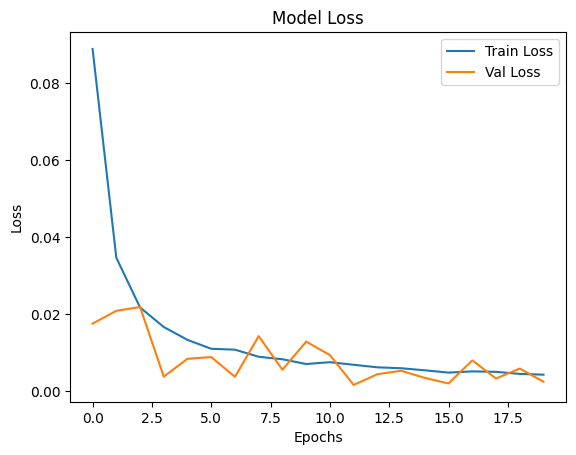

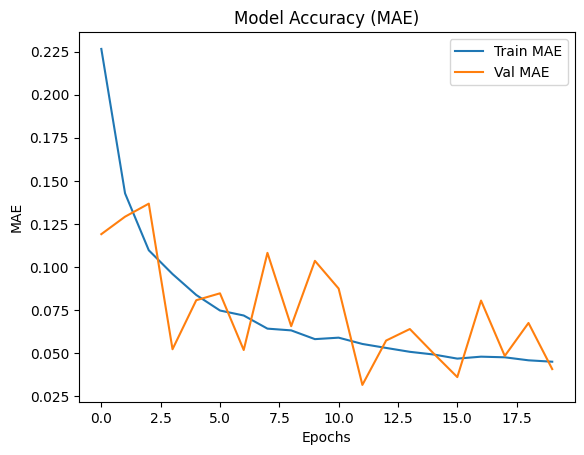

In [4]:
# -----------------------------------------------------------
# STEP 1: Import dependencies
# -----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer
from scikeras.wrappers import KerasRegressor
import tensorflow as tf
from tensorflow.keras import layers, models

# -----------------------------------------------------------
# STEP 2: Load dataset
# -----------------------------------------------------------
df = pd.read_csv("/content/drive/MyDrive/edurekaai/_data/samples/Tesla.csv")

# Convert 'Date' column to datetime
df["Date"] = pd.to_datetime(df["Date"])

# -----------------------------------------------------------
# STEP 3: Train-validation split (sequential, no shuffle)
# -----------------------------------------------------------
len_data = len(df)
split_ratio = 0.8
len_train = int(len_data * split_ratio)

train_data = df[:len_train].iloc[:, :2]   # keep only [Date, Open]
val_data = df[len_train:].iloc[:, :2]

# -----------------------------------------------------------
# STEP 4: Extract series (Open price only)
# -----------------------------------------------------------
train_series = train_data["Open"].values.reshape(-1, 1)
val_series = val_data["Open"].values.reshape(-1, 1)

# -----------------------------------------------------------
# STEP 5: Preprocessing
# -----------------------------------------------------------
# Scale values between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_series)
val_scaled = scaler.transform(val_series)

# -----------------------------------------------------------
# STEP 6: Create time-series windows
# -----------------------------------------------------------
def create_sequences(series, window_size=50):
    """
    Converts a 1D array into (X, y) pairs for RNN training.
    Each X has `window_size` steps, y is the next value.
    """
    x, y = [], []
    for i in range(window_size, len(series)):
        x.append(series[i-window_size:i, 0])  # past 50 steps (50 days data)
        y.append(series[i, 0])                # next step
    x, y = np.array(x), np.array(y)
    return x.reshape(x.shape[0], x.shape[1], 1), y

x_train, y_train = create_sequences(train_scaled, window_size=50)
x_val, y_val = create_sequences(val_scaled, window_size=50)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

# -----------------------------------------------------------
# STEP 7: Define RNN model
# -----------------------------------------------------------
def build_rnn_model(input_features=50):
    """
    Builds a stacked SimpleRNN model for time series forecasting.
    """
    model = models.Sequential([
        layers.SimpleRNN(units=input_features, activation="tanh",
                         return_sequences=True, input_shape=(input_features, 1)),
        layers.Dropout(0.2),

        layers.SimpleRNN(units=50, activation="tanh", return_sequences=True),
        layers.Dropout(0.2),

        layers.SimpleRNN(units=50, activation="tanh"),
        layers.Dropout(0.2),

        layers.Dense(units=1, activation="tanh")
    ])
    model.compile(optimizer="adam",
                  loss="mean_squared_error",
                  metrics=["mae"])
    return model

# -----------------------------------------------------------
# STEP 8: Wrap in SciKeras for pipeline compatibility
# -----------------------------------------------------------
rnn_regressor = KerasRegressor(
    model=build_rnn_model,
    model__input_features=50,
    epochs=20,
    batch_size=32,
    verbose=0,
    fit__verbose=2
)

# -----------------------------------------------------------
# STEP 9: Build pipeline
# -----------------------------------------------------------
# (Normally, you’d put preprocessing inside the pipeline,
# but here we already pre-windowed the time series)
pipeline = Pipeline([
    ("rnn", rnn_regressor)
])

# -----------------------------------------------------------
# STEP 10: Train model
# -----------------------------------------------------------
history = pipeline.fit(x_train, y_train, rnn__validation_data=(x_val, y_val))

# Extract Keras history
hist = pipeline.named_steps["rnn"].model_.history

# -----------------------------------------------------------
# STEP 11: Visualization
# -----------------------------------------------------------
# Plot training & validation loss
plt.plot(hist.history["loss"], label="Train Loss")
plt.plot(hist.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Plot MAE
plt.plot(hist.history["mae"], label="Train MAE")
plt.plot(hist.history["val_mae"], label="Val MAE")
plt.title("Model Accuracy (MAE)")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()
